In [3]:
# Task 1 : Data Preparation

import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("C:\\Users\\Lenovo\\OneDrive\\Desktop\\ml-assignment-satvinder-singh\\data\\q2_customers.csv")

features = df.columns
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

Scaling is required before K-Means because it is based on Euclidean distance. Without scaling, features with larger values such as annual_spend would dominate and distort the clustering results.

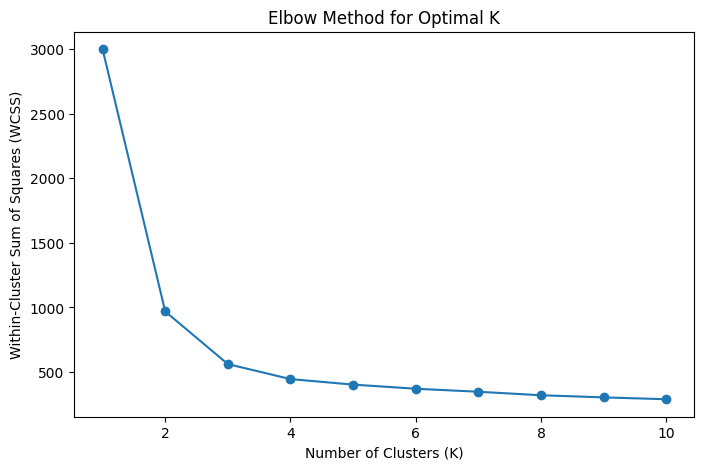

In [5]:
# Task 2 : Choosing K -- Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

# Try K values from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)
    
# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.show()

The elbow is observed at K=4 (based on the plot), where the decrease in WCSS starts slowing down. This indicates that 4 clusters best represent the data without making the model too complex.

In [6]:
# Task 3 : K-Means Clustering

from sklearn.cluster import KMeans
import pandas as pd

# Choose K (replace with your Elbow Method)
k = 4

# Fit K-Means
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_data)

# Show cluster centroids as dataframe for better visualization
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=df.columns[:-1]
)
print("Cluster Centroids :")
print(centroids)

Cluster Centroids :
        age  annual_spend  visits_per_month  basket_size  \
0 -1.094595     -1.036122          1.114284    -0.934278   
1  1.150795      1.247783         -1.118857     1.150217   
2 -0.004449     -0.168055         -0.041370    -0.290670   
3  1.114725      1.224083         -1.095219     1.350241   

   days_since_last_visit  num_categories_purchased  
0              -0.813494                 -1.045346  
1               1.984595                  1.161639  
2              -0.287579                 -0.095968  
3               0.317376                  1.183676  


Cluster 0 represents frequent visitors with low spending and low product variety.
Cluster 1 represents high-value customers with high spending but low visit frequency.
Cluster 2 represents average customers with moderate spending and balanced behavior.
Cluster 3 represents premium customers with high spending and high product variety.

In [8]:
# Task 4 : Dimensionality Reduction with PCA

from sklearn.decomposition import PCA
import pandas as pd

# Apply PCA (2 components)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# Explained variance ratio
print("Explained Variance Ratio :", pca.explained_variance_ratio_)

# Feature loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)
print("Feature Loadings :")
print(loadings)

Explained Variance Ratio : [0.83560354 0.05568764]
Feature Loadings :
          age  annual_spend  visits_per_month  basket_size  \
PC1  0.411569       0.42154         -0.410399     0.412012   
PC2 -0.259432      -0.03327          0.208318    -0.195402   

     days_since_last_visit  num_categories_purchased  
PC1               0.378582                  0.414017  
PC2               0.911194                 -0.140479  


PC1 captures overall customer value and spending behavior, while PC2 captures recency and visit-related activity differences among customers.

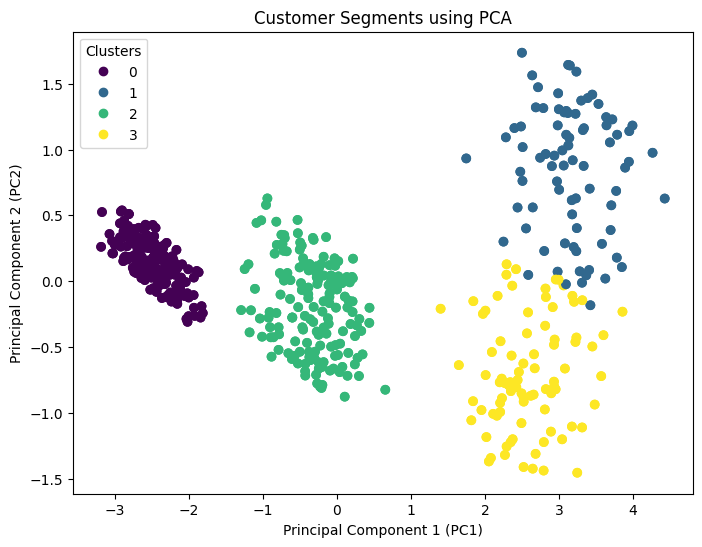

In [12]:
# Task 5 : Cluster Visualisation

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=df['Cluster'],
    cmap='viridis',
)

plt.title("Customer Segments using PCA")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
scatter = plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=df['Cluster'],
    cmap='viridis',
)

plt.title("Customer Segments using PCA")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

The PCA scatter plot shows customer segments clearly in 2D space, with different clusters formed based on their behavior patterns in PC1 and PC2.